In [1]:
import rebound
import numpy as np
from tqdm import tqdm
from scipy import signal
import matplotlib.pyplot as plt
from celmech import Poincare, PoincareHamiltonian
from celmech.disturbing_function import laplace_b, df_coefficient_Ctilde, evaluate_df_coefficient_dict


m_sat = 2.85837e-4
m_jup = 9.945786e-4
m_c = 1

def ft(times, x):
    fs = 1/((times[1] - times[0])/(2*np.pi))
    f, pxx = signal.periodogram(x,fs=fs,window='hann',scaling='density')
    return f,pxx

def pomega_ft(times,pomega,ecc):
    k = ecc*np.cos(pomega)
    h = ecc*np.sin(pomega)*1j
    z = h + k
    f,pxx = ft(times, z)
    return f,pxx

#from celmech docs
def get_pomega(kap,eta):
    return np.arctan2(-eta,kap)

def get_ecc(kap,eta,L):
    P = (kap**2 + eta**2)/2
    return np.sqrt(1 - (1 - P/L)**2)

## Got direct term using cel-mech

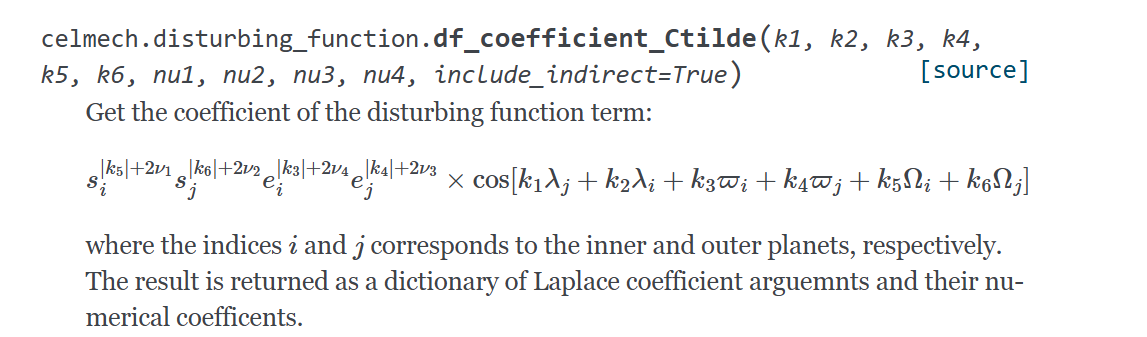

## Saturn Test Particle

In [18]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=1)


a_12 = pham.state.particles[2].a
n12 = pham.state.particles[2].n

alpha12 = 5.6/8.9

sim.move_to_com()

fd_21_k4 = evaluate_df_coefficient_dict(
    df_coefficient_Ctilde(k1=2, k2=-1, k3=0, k4=-1, k5=0, k6=0,
                          nu1=0, nu2=0, nu3=0, nu4=0, include_indirect = False), alpha12)

In [19]:
#using the convention that G = 1, in solar masses
#these were all evaluated using the textbook Murray and Dermot

# alpha is 0.62921348314
alpha = 5.6/8.9

'''b_2_05 = laplace_b(0.5, 2, 0,alpha)
b_2_05_deriv = laplace_b(0.5, 2, 1,alpha)

b_5_05 = laplace_b(0.5, 5, 0,alpha)
b_5_05_deriv = laplace_b(0.5, 5, 1,alpha)
b_5_05_deriv2 = laplace_b(0.5, 5, 2,alpha)

#for 2:1 where j=2
fd_21 = 0.5*(-4*b_2_05 - alpha*b_2_05_deriv)

alpha_53 = 5.6/7.872

#for 5:3 where j = 5
fd_53 = (1.8)*((-10 + 4*25)*b_5_05 + (-2*alpha_53 + 4*5*alpha_53)*b_5_05_deriv + alpha_53*b_5_05_deriv2)'''


'b_2_05 = laplace_b(0.5, 2, 0,alpha)\nb_2_05_deriv = laplace_b(0.5, 2, 1,alpha)\n\nb_5_05 = laplace_b(0.5, 5, 0,alpha)\nb_5_05_deriv = laplace_b(0.5, 5, 1,alpha)\nb_5_05_deriv2 = laplace_b(0.5, 5, 2,alpha)\n\n#for 2:1 where j=2\nfd_21 = 0.5*(-4*b_2_05 - alpha*b_2_05_deriv)\n\nalpha_53 = 5.6/7.872\n\n#for 5:3 where j = 5\nfd_53 = (1.8)*((-10 + 4*25)*b_5_05 + (-2*alpha_53 + 4*5*alpha_53)*b_5_05_deriv + alpha_53*b_5_05_deriv2)'

In [20]:
#using celmech for the calculation to get the 53
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=7.872,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha53 = 5.6/7.872

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=5,q=2,indexIn=1, indexOut=2, max_order=2)

n53 = pham.state.particles[2].n

fd_53 = df_coefficient_Ctilde(k1=5, k2=-3, k3=0, k4=-2, k5=0, k6=0, nu1=0, nu2=0, nu3=0, nu4=0, include_indirect = False)

fd_53 = evaluate_df_coefficient_dict(fd_53, alpha53)

In [21]:
#using celmech for the calculation to get the 74
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.132,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha74 = 5.6/8.132

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=7,q=3,indexIn=1, indexOut=2, max_order=3)

n74 = pham.state.particles[2].n

fd_74 = df_coefficient_Ctilde(k1=7, k2=-4, k3=0, k4=-3, k5=0, k6=0, nu1=0, nu2=0, nu3=0, nu4=0, include_indirect = False)

fd_74 = evaluate_df_coefficient_dict(fd_74, alpha74)

In [22]:
#using celmech for the calculation to get the 9:5
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.286,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha95 = 5.6/8.286

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=9,q=4,indexIn=1, indexOut=2, max_order=4)

n95 = pham.state.particles[2].n

fd_95 = df_coefficient_Ctilde(k1=9, k2=-5, k3=0, k4=-4, k5=0, k6=0, nu1=0, nu2=0, nu3=0, nu4=0, include_indirect = False)

fd_95 = evaluate_df_coefficient_dict(fd_95, alpha95)

In [23]:
#using celmech for the calculation to get the 9:4
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=9.616,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha94 = 5.6/9.616

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=9,q=5,indexIn=1, indexOut=2, max_order=5)

n94 = pham.state.particles[2].n

fd_94 = df_coefficient_Ctilde(k1=9, k2=-4, k3=0, k4=-5, k5=0, k6=0, nu1=0, nu2=0, nu3=0, nu4=0, include_indirect = False)

fd_94 = evaluate_df_coefficient_dict(fd_94, alpha94)

In [24]:
#def c_r(m, n, alpha, fd):
    #return m*n*alpha*fd

def c_r(m, n, alpha):
    return m * n * alpha

c_r_21 = c_r(m_jup,n12,alpha12)

c_r_53 = c_r(m_jup, n53, alpha53)

c_r_74 = c_r(m_jup, n74, alpha74)

c_r_95 = c_r(m_jup, n95, alpha95)

c_r_94 = c_r(m_jup, n94, alpha94)

def a_max_21(e, c_r_val, fd, n, a, j2):
    x = (np.abs(c_r_val) / n) * np.abs(fd)
    return a * (np.sqrt((16/3) * x * e) * np.sqrt(1 + x/(27 * j2**2 * e**3)) - (2/(9 * j2 * e)) * x)

def a_max(e, c_r_val, fd, n, a, order):
    return a * np.sqrt((16/3) * (c_r_val/n) * np.abs(fd) * e**order)

/tmp/ipykernel_949/1190788945.py:19: RuntimeWarning: divide by zero encountered in divide
  return a * (np.sqrt((16/3) * x * e) * np.sqrt(1 + x/(27 * j2**2 * e**3)) - (2/(9 * j2 * e)) * x)
/tmp/ipykernel_949/1190788945.py:19: RuntimeWarning: invalid value encountered in multiply
  return a * (np.sqrt((16/3) * x * e) * np.sqrt(1 + x/(27 * j2**2 * e**3)) - (2/(9 * j2 * e)) * x)


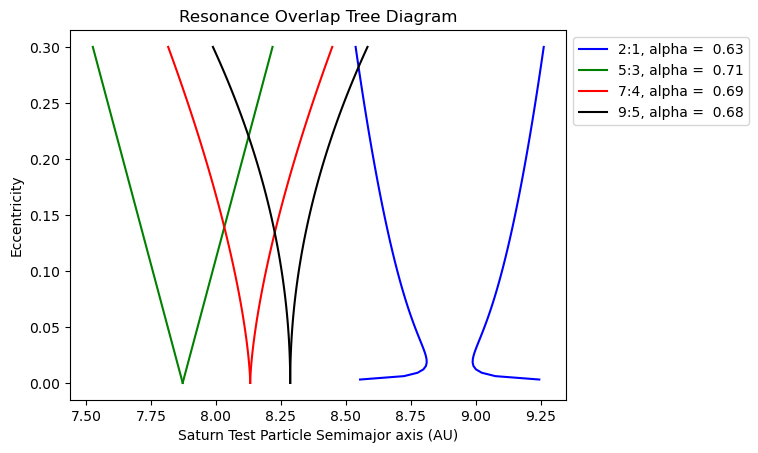

In [25]:
ecc_vals = np.linspace(0,0.3,100)

#plt.plot(a_sat + width_vals, ecc_vals,color = 'blue')
#plt.plot(a_sat - width_vals, ecc_vals, color = 'blue', label = '2:1')
plt.plot(8.9 + a_max_21(ecc_vals, c_r_21,fd_21_k4, n12, 8.9,2),ecc_vals, color = 'blue', label = f'2:1, alpha = {alpha12: .2f}')
plt.plot(8.9 - a_max_21(ecc_vals, c_r_21,fd_21_k4, n12, 8.9,2),ecc_vals, color = 'blue')
plt.plot(7.872 + a_max(ecc_vals, c_r_53,fd_53, n53, 7.872, 2),ecc_vals, color = 'green', label = f'5:3, alpha = {alpha53: .2f}')
plt.plot(7.872 - a_max(ecc_vals, c_r_53,fd_53, n53, 7.872, 2),ecc_vals, color = 'green')
plt.plot(8.132 + a_max(ecc_vals, c_r_74,fd_74, n74, 8.132, 3), ecc_vals, color = 'red', label = f'7:4, alpha = {alpha74: .2f}')
plt.plot(8.132 - a_max(ecc_vals, c_r_74,fd_74, n74, 8.132, 3), ecc_vals, color = 'red')
plt.plot(8.286 + a_max(ecc_vals, c_r_95,fd_95, n95, 8.286, 4), ecc_vals, color = 'black', label = f'9:5, alpha = {alpha95: .2f}')
plt.plot(8.286 - a_max(ecc_vals, c_r_95,fd_95, n95, 8.286, 4), ecc_vals, color = 'black')
#plt.plot(9.616 + a_max(ecc_vals, c_r_94,fd_94, n94, 9.616, 5), ecc_vals, color = 'purple', label = f'9:4, alpha = {alpha94: .2f}')
#plt.plot(9.616 - a_max(ecc_vals, c_r_94,fd_94, n94, 9.616, 5), ecc_vals, color = 'purple')
plt.ylabel('Eccentricity')
plt.xlabel('Saturn Test Particle Semimajor axis (AU)')
plt.title('Resonance Overlap Tree Diagram')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left',markerscale=1.0)
plt.show()

## Jupiter Test Particle

In [29]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=1e-10,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=1)

a_12 = pham.state.particles[1].a
n12 = pham.state.particles[1].n

alpha12 = 5.6/8.9

sim.move_to_com()

fd_21 = evaluate_df_coefficient_dict(
    df_coefficient_Ctilde(k1=2, k2=-1, k3=-1, k4=0, k5=0, k6=0,
                          nu1=0, nu2=0, nu3=0, nu4=0, include_indirect = False), alpha12)

sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=6.331,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha53 = 6.331/8.9

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=5,q=2,indexIn=1, indexOut=2, max_order=2)

n53 = pham.state.particles[1].n

fd_53 = df_coefficient_Ctilde(k1=5, k2=-3, k3=-2, k4=0, k5=0, k6=0, nu1=0, nu2=0, nu3=0, nu4=0, include_indirect = False)

fd_53 = evaluate_df_coefficient_dict(fd_53, alpha53)

sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=6.129,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha74 = 6.129/8.9

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=7,q=3,indexIn=1, indexOut=2, max_order=3)

n74 = pham.state.particles[1].n

fd_74 = df_coefficient_Ctilde(k1=7, k2=-4, k3=-3, k4=0, k5=0, k6=0, nu1=0, nu2=0, nu3=0, nu4=0, include_indirect = False)

fd_74 = evaluate_df_coefficient_dict(fd_74, alpha74)

sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=6.015,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha95 = 6.015/8.9

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=9,q=4,indexIn=1, indexOut=2, max_order=4)

n95 = pham.state.particles[1].n

fd_95 = df_coefficient_Ctilde(k1=9, k2=-5, k3=-4, k4=0, k5=0, k6=0, nu1=0, nu2=0, nu3=0, nu4=0, include_indirect = False)

fd_95 = evaluate_df_coefficient_dict(fd_95, alpha95)

In [30]:
def c_r(m, n, alpha):
    return m * n * alpha

c_r_21 = c_r(m_jup,n12,alpha12)

c_r_53 = c_r(m_jup, n53, alpha53)

c_r_74 = c_r(m_jup, n74, alpha74)

c_r_95 = c_r(m_jup, n95, alpha95)

#c_r_94 = c_r(m_jup, n94, alpha94)

def a_max_21(e, c_r_val, fd, n, a, j2):
    x = (np.abs(c_r_val) / n) * np.abs(fd)
    return a * (np.sqrt((16/3) * x * e) * np.sqrt(1 + x/(27 * j2**2 * e**3)) - (2/(9 * j2 * e)) * x)

def a_max(e, c_r_val, fd, n, a, order):
    return a * np.sqrt((16/3) * (c_r_val/n) * np.abs(fd) * e**order)

/tmp/ipykernel_949/1345513553.py:16: RuntimeWarning: divide by zero encountered in divide
  return a * (np.sqrt((16/3) * x * e) * np.sqrt(1 + x/(27 * j2**2 * e**3)) - (2/(9 * j2 * e)) * x)
/tmp/ipykernel_949/1345513553.py:16: RuntimeWarning: invalid value encountered in multiply
  return a * (np.sqrt((16/3) * x * e) * np.sqrt(1 + x/(27 * j2**2 * e**3)) - (2/(9 * j2 * e)) * x)


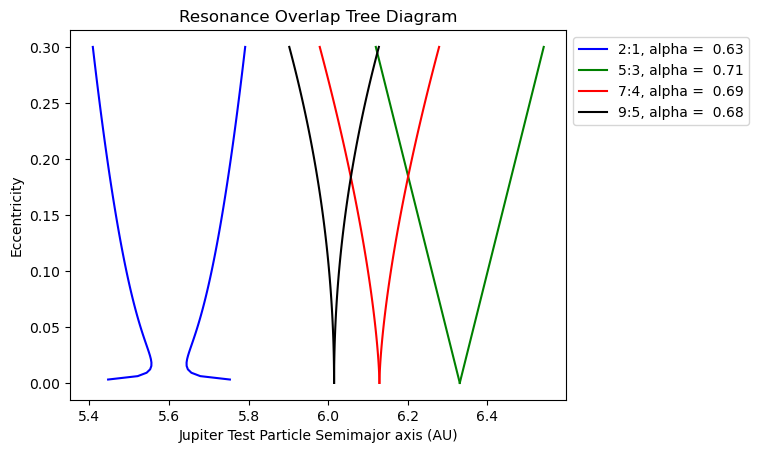

In [31]:
ecc_vals = np.linspace(0,0.3,100)

#plt.plot(a_sat + width_vals, ecc_vals,color = 'blue')
#plt.plot(a_sat - width_vals, ecc_vals, color = 'blue', label = '2:1')
plt.plot(5.6 + a_max_21(ecc_vals, c_r_21,fd_21, n12, 5.6,2),ecc_vals, color = 'blue', label = f'2:1, alpha = {alpha12: .2f}')
plt.plot(5.6 - a_max_21(ecc_vals, c_r_21,fd_21, n12, 5.6,2),ecc_vals, color = 'blue')
plt.plot(6.331 + a_max(ecc_vals, c_r_53,fd_53, n53, 6.331, 2),ecc_vals, color = 'green', label = f'5:3, alpha = {alpha53: .2f}')
plt.plot(6.331 - a_max(ecc_vals, c_r_53,fd_53, n53, 6.331, 2),ecc_vals, color = 'green')
plt.plot(6.129 + a_max(ecc_vals, c_r_74,fd_74, n74, 6.129, 3), ecc_vals, color = 'red', label = f'7:4, alpha = {alpha74: .2f}')
plt.plot(6.129 - a_max(ecc_vals, c_r_74,fd_74, n74, 6.129, 3), ecc_vals, color = 'red')
plt.plot(6.015 + a_max(ecc_vals, c_r_95,fd_95, n95, 6.015, 4), ecc_vals, color = 'black', label = f'9:5, alpha = {alpha95: .2f}')
plt.plot(6.015 - a_max(ecc_vals, c_r_95,fd_95, n95, 6.015, 4), ecc_vals, color = 'black')

plt.ylabel('Eccentricity')
plt.xlabel('Jupiter Test Particle Semimajor axis (AU)')
plt.title('Resonance Overlap Tree Diagram')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left',markerscale=1.0)
plt.show()